In [78]:
from memo import memo
import jax
import jax.numpy as np
from enum import IntEnum, auto

In [79]:
class Role(IntEnum): Fighter = 0; Tank = 1; Healer = 2
class Action(IntEnum): Attack = 0; Defend = 1; Heal = 2
class EnemyHealth(IntEnum): CRITICAL = 0; LOW = 1; MEDIUM = 2; HIGH = 3; FULL = 4

# State is the enemy's health discretized into 5 levels: CRITICAL, LOW, MEDIUM, HIGH, FULL
# Actions: Attack (damage enemy), Defend (protect team), Heal (support team)
# Transition depends on how many players attack vs enemy's random healing

# ROLE_ACTION_STATE_PROBS[role, enemy_health, action]
# Probabilities: P(action | role, enemy_health)
ROLE_ACTION_STATE_PROBS = np.array([
    # Fighter probabilities [enemy_health, action]
    [
        [0.85, 0.10, 0.05],  # CRITICAL: attack aggressively to finish (85% attack)
        [0.80, 0.15, 0.05],  # LOW: keep attacking (80% attack)
        [0.70, 0.25, 0.05],  # MEDIUM: mostly attack (70% attack)
        [0.65, 0.30, 0.05],  # HIGH: attack with some caution (65% attack)
        [0.60, 0.35, 0.05],  # FULL: attack but be careful (60% attack)
    ],
    # Tank probabilities [enemy_health, action]
    [
        [0.15, 0.80, 0.05],  # CRITICAL: still defend team (80% defend)
        [0.20, 0.70, 0.10],  # LOW: mostly defend (70% defend)
        [0.25, 0.70, 0.05],  # MEDIUM: defend (70% defend)
        [0.10, 0.80, 0.10],  # HIGH: defend more when enemy strong (80% defend)
        [0.05, 0.90, 0.05],  # FULL: defend heavily (90% defend)
    ],
    # Healer probabilities [enemy_health, action]
    [
        [0.20, 0.10, 0.70],  # CRITICAL: support team (70% heal)
        [0.15, 0.10, 0.75],  # LOW: mostly heal (75% heal)
        [0.25, 0.05, 0.70],  # MEDIUM: heal (70% heal)
        [0.10, 0.10, 0.80],  # HIGH: heal more when enemy strong (80% heal)
        [0.05, 0.05, 0.90],  # FULL: heal heavily (90% heal)
    ],
])

@jax.jit
def role_policy(role, action, enemy_health):  # role-conditioned action likelihood P(action | role, enemy_health)
    return ROLE_ACTION_STATE_PROBS[role, enemy_health, action]

# Transition probability matrix [num_attackers, change_type]
# change_type: 0 = decrease health, 1 = stay same, 2 = increase health (enemy heals)
# Boss is very difficult - heals frequently and resists damage
TRANSITION_PROBS = np.array([
    [0.0, 0.15, 0.85],   # 0 attackers: 85% heal, 15% stay (boss regenerates rapidly!)
    [0.20, 0.50, 0.30],  # 1 attacker: 20% decrease, 50% stay, 30% heal (still healing!)
    [0.45, 0.40, 0.15],  # 2 attackers: 45% decrease, 40% stay, 15% heal (coordination matters)
    [0.70, 0.25, 0.05],  # 3 attackers: 70% decrease, 25% stay, 5% heal (full team needed!)
])

@jax.jit
def Transition(current_enemy_health, num_attackers, key):
    """
    Update enemy health state based on number of attackers.
    
    Args:
        current_enemy_health: Current enemy health state (0=CRITICAL to 4=FULL)
        num_attackers: Number of players attacking (0-3)
        key: JAX random key for stochasticity
    
    Returns:
        next_enemy_health: Updated enemy health state
    
    Transition logic:
    - Boss is VERY difficult and heals frequently
    - More attackers -> higher chance enemy loses health
    - Full team coordination (3 attackers) needed to reliably damage boss
    - Enemy can't go below CRITICAL or above FULL
    """
    
    # Clamp num_attackers to valid range
    num_attackers = np.clip(num_attackers, 0, 3)
    
    # Get probabilities based on number of attackers
    probs = TRANSITION_PROBS[num_attackers]
    
    # Sample the change (-1, 0, +1)
    change = jax.random.choice(key, np.array([-1, 0, 1]), p=probs)
    
    # Apply change with bounds
    next_health = np.clip(current_enemy_health + change, 0, 4)
    
    return next_health

@jax.jit
def get_element(array, i0, i1, i2):
    return array[i0, i1, i2]


In [80]:
@memo
def role_inference[r0 : Role, r1 : Role, r2 : Role](role_prior, obs_a0, obs_a1, obs_a2, enemy_health):
    observer: knows(r0, r1, r2) # Push array axis variables into observer's frame
    observer: thinks[
        team: assigned(r0 in Role, r1 in Role, r2 in Role, wpp=get_element(role_prior, r0, r1, r2)), # Assign roles to each player
        team: chooses(a0 in Action, wpp=role_policy(r0, a0, enemy_health)), # Choose player 0's action (a0) according to their role (r0)
        team: chooses(a1 in Action, wpp=role_policy(r1, a1, enemy_health)), # Choose player 1's action (a1) according to their role (r1)
        team: chooses(a2 in Action, wpp=role_policy(r2, a2, enemy_health))  # Choose player 2's action (a2) according to their role (r2)
    ]
    observer: observes_that [team.a0 == obs_a0] # Observe player 0's action
    observer: observes_that [team.a1 == obs_a1] # Observe player 1's action
    observer: observes_that [team.a2 == obs_a2] # Observe player 2's action
    return observer[Pr[r0 == team.r0 and r1 == team.r1 and r2 == team.r2]]

# Specify role prior
role_prior = np.ones((3, 3, 3))
# Create a constrained prior that ensures role uniqueness
i, j, k = np.indices((3, 3, 3))
mask = (i != j) & (i != k) & (j != k)
constrained_prior = mask.astype(np.float32)

# Specify observed actions
actions = [Action.Heal, Action.Defend, Action.Heal]
# Run inference and print results
role_probs = role_inference(role_prior, *actions, enemy_health=EnemyHealth.MEDIUM, print_table=True)

+----------+----------+----------+-------------------------+
| r0: Role | r1: Role | r2: Role | role_inference          |
+----------+----------+----------+-------------------------+
| Fighter  | Fighter  | Fighter  | 0.0009765625            |
| Fighter  | Fighter  | Tank     | 0.0009765625            |
| Fighter  | Fighter  | Healer   | 0.013671874068677425    |
| Fighter  | Tank     | Fighter  | 0.002734375186264515    |
| Fighter  | Tank     | Tank     | 0.002734375186264515    |
| Fighter  | Tank     | Healer   | 0.03828125074505806     |
| Fighter  | Healer   | Fighter  | 0.00019531248835846782  |
| Fighter  | Healer   | Tank     | 0.00019531248835846782  |
| Fighter  | Healer   | Healer   | 0.002734375186264515    |
| Tank     | Fighter  | Fighter  | 0.0009765625            |
| Tank     | Fighter  | Tank     | 0.0009765625            |
| Tank     | Fighter  | Healer   | 0.013671874068677425    |
| Tank     | Tank     | Fighter  | 0.002734375186264515    |
| Tank     | Tank     | 

In [81]:
import random

def marginalize(role_probs, agent_idx):
    """Marginalize role probabilities to get distribution for a single agent."""
    if agent_idx == 0:
        return np.sum(role_probs, axis=(1, 2))
    elif agent_idx == 1:
        return np.sum(role_probs, axis=(0, 2))
    else:  # agent_idx == 2
        return np.sum(role_probs, axis=(0, 1))

def simulate_role_convergence(n_steps, role_prior, initial_enemy_health=EnemyHealth.FULL, seed=42):
    """
    Simulate the role coordination game with enemy health dynamics.
    Stops when enemy reaches CRITICAL health (death) or max steps reached.
    
    Args:
        n_steps: Maximum number of timesteps to simulate
        role_prior: Initial prior over role assignments [3x3x3]
        initial_enemy_health: Starting enemy health state
        seed: Random seed for reproducibility
    
    Returns:
        role_history: History of sampled roles [actual_steps x 3]
        action_history: History of sampled actions [actual_steps x 3]
        role_prob_history: History of role beliefs [actual_steps x 3x3x3]
        enemy_health_history: History of enemy health states [actual_steps + 1] (includes final state)
        actual_steps: Actual number of action steps taken
        victory: Whether the enemy was defeated
    """
    random.seed(seed)
    key = jax.random.PRNGKey(seed)
    
    role_probs = role_prior
    enemy_health = initial_enemy_health
    
    # Preallocate arrays for histories
    role_history = np.zeros((n_steps, 3), dtype=np.int32)
    action_history = np.zeros((n_steps, 3), dtype=np.int32)
    role_prob_history = np.zeros((n_steps, 3, 3, 3), dtype=np.float32)
    enemy_health_history = np.zeros(n_steps + 1, dtype=np.int32)  # +1 to store final state
    
    # Store initial enemy health
    enemy_health_history = enemy_health_history.at[0].set(enemy_health)
    
    for t in range(n_steps):
        # Sample a role for each agent according to the marginal distribution over their role
        roles = [random.choices([0, 1, 2], weights=marginalize(role_probs, i))[0] for i in range(3)]
        role_history = role_history.at[t].set(np.array(roles))  # Store roles

        # Sample an action for each agent according to the role policy conditioned on enemy health
        actions = [random.choices([0, 1, 2], weights=ROLE_ACTION_STATE_PROBS[r, enemy_health, :])[0] for r in roles]
        action_history = action_history.at[t].set(np.array(actions))  # Store actions

        # Update (common) beliefs about role assignments via role inference
        role_probs = role_inference(role_probs, *actions, enemy_health=enemy_health)
        role_prob_history = role_prob_history.at[t].set(role_probs)  # Store updated probabilities
        
        # Count number of attackers (Action.Attack == 0)
        num_attackers = sum(1 for a in actions if a == Action.Attack)
        
        # Update enemy health using Transition function
        key, subkey = jax.random.split(key)
        enemy_health = Transition(enemy_health, num_attackers, subkey)
        
        # Store new enemy health (at position t+1)
        enemy_health_history = enemy_health_history.at[t + 1].set(enemy_health)
        
        # Check if enemy is dead (CRITICAL = 0) AFTER the transition
        if enemy_health == EnemyHealth.CRITICAL:
            print(f"\n🎉 Victory! Enemy defeated at step {t + 1}!")
            actual_steps = t + 1
            victory = True
            break
    else:
        # Loop completed without break - enemy survived all steps
        actual_steps = n_steps
        victory = False
        print(f"\n💀 Defeat! Enemy survived {n_steps} steps with {EnemyHealth(enemy_health).name} health remaining.")

    # Trim arrays to actual length
    role_history = role_history[:actual_steps]
    action_history = action_history[:actual_steps]
    role_prob_history = role_prob_history[:actual_steps]
    enemy_health_history = enemy_health_history[:actual_steps + 1]  # +1 to include final state

    return role_history, action_history, role_prob_history, enemy_health_history, actual_steps, victory



🎉 Victory! Enemy defeated at step 26!

Simulation ran for 26 action steps

Simulation History (First 10 Steps):
Timestep   | Enemy HP   | Player 0        | Player 1        | Player 2       
-------------------------------------------------------------------------------------
Step 1     | FULL       | Fighter         | Fighter         | Tank           
           |            | Attack          | Defend          | Attack         
Step 2     | FULL       | Healer          | Tank            | Healer         
           |            | Heal            | Defend          | Heal           
Step 3     | FULL       | Fighter         | Fighter         | Fighter        
           |            | Attack          | Attack          | Attack         
Step 4     | FULL       | Fighter         | Tank            | Healer         
           |            | Attack          | Defend          | Heal           
Step 5     | FULL       | Fighter         | Tank            | Healer         
           |         

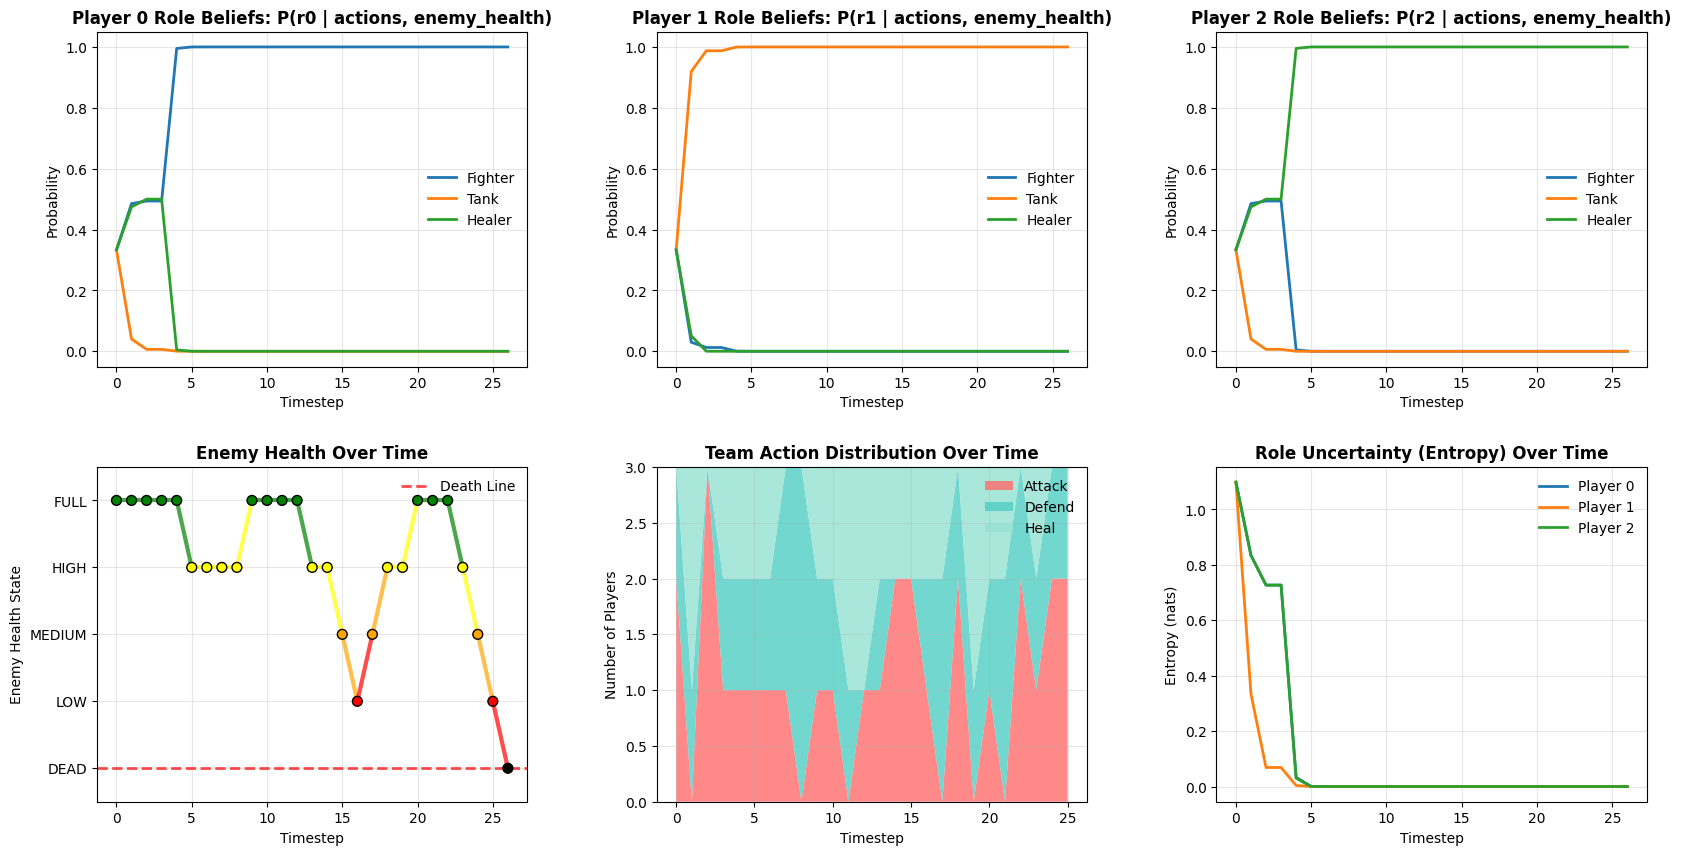


FINAL STATISTICS
Battle Duration: 26 action steps
Final Enemy Health: CRITICAL
Result: 🎉 VICTORY! 🎉

Final role assignment (most likely):
  Player 0: Fighter
  Player 1: Tank
  Player 2: Healer

Action Distribution:
  Attacks: 29/78 (37.2%)
  Defends: 27/78 (34.6%)
  Heals: 22/78 (28.2%)

MULTIPLE SIMULATION RUNS

🎉 Victory! Enemy defeated at step 38!
Seed 42: 38 steps, Final HP: CRITICAL -> 🎉 WIN

🎉 Victory! Enemy defeated at step 26!
Seed 123: 26 steps, Final HP: CRITICAL -> 🎉 WIN

🎉 Victory! Enemy defeated at step 18!
Seed 456: 18 steps, Final HP: CRITICAL -> 🎉 WIN

🎉 Victory! Enemy defeated at step 7!
Seed 789: 7 steps, Final HP: CRITICAL -> 🎉 WIN

🎉 Victory! Enemy defeated at step 19!
Seed 999: 19 steps, Final HP: CRITICAL -> 🎉 WIN


In [82]:
# Run simulation
max_steps = 100
role_prior = constrained_prior  # Use constrained prior for unique roles
seed = 123  # Try different seeds: 42, 123, 456, 789, etc.

role_history, action_history, role_prob_history, enemy_health_history, n_steps, victory = simulate_role_convergence(
    max_steps, role_prior, initial_enemy_health=EnemyHealth.FULL, seed=seed
)

print(f"\nSimulation ran for {n_steps} action steps")
print("\nSimulation History (First 10 Steps):")
print(f"{'Timestep':<10} | {'Enemy HP':<10} | {'Player 0':<15} | {'Player 1':<15} | {'Player 2':<15}")
print("-" * 85)

for t in range(min(10, n_steps)):
    roles = [Role(r).name for r in role_history[t]]
    actions = [Action(a).name for a in action_history[t]]
    enemy_hp = EnemyHealth(int(enemy_health_history[t])).name
    print(f"{f'Step {t+1}':<10} | {enemy_hp:<10} | {roles[0]:<15} | {roles[1]:<15} | {roles[2]:<15}")
    print(f"{'':<10} | {'':<10} | {actions[0]:<15} | {actions[1]:<15} | {actions[2]:<15}")

import matplotlib.pyplot as plt
import numpy as onp  # Use original numpy for non-JAX operations

# Create a figure with 4 subplots: 3 for role probabilities + 1 for enemy health
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Top row: Role probability evolution for each player
for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    
    # Calculate marginal probabilities for the current player at each timestep
    player_role_probs = [marginalize(role_prob_history[t], i) for t in range(n_steps)]
    # Add the initial timestep's probabilities
    player_role_probs.insert(0, marginalize(role_prior / role_prior.sum(), i))
    player_role_probs = onp.array(player_role_probs)

    # Plot the evolution of role probabilities for the current player
    for role in Role:
        ax.plot(range(n_steps + 1), player_role_probs[:, role], label=role.name, linewidth=2)

    ax.set_title(f'Player {i} Role Beliefs: P(r{i} | actions, enemy_health)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Probability')
    ax.legend(frameon=False, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

# Bottom left: Enemy health over time
ax_health = fig.add_subplot(gs[1, 0])
health_names = ['DEAD', 'LOW', 'MEDIUM', 'HIGH', 'FULL']
health_colors = ['black', 'red', 'orange', 'yellow', 'green']
enemy_health_arr = onp.array(enemy_health_history)

# Plot with color coding
for i in range(len(enemy_health_arr) - 1):
    color = health_colors[int(enemy_health_arr[i])]
    ax_health.plot([i, i+1], [enemy_health_arr[i], enemy_health_arr[i+1]], 
                   color=color, linewidth=3, alpha=0.7)
    
ax_health.scatter(range(len(enemy_health_arr)), enemy_health_arr, 
                 c=[health_colors[int(h)] for h in enemy_health_arr], 
                 s=50, zorder=3, edgecolors='black', linewidth=1)
ax_health.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Death Line', alpha=0.7)
ax_health.set_title('Enemy Health Over Time', fontsize=12, fontweight='bold')
ax_health.set_xlabel('Timestep')
ax_health.set_ylabel('Enemy Health State')
ax_health.set_yticks(range(5))
ax_health.set_yticklabels(health_names)
ax_health.legend(frameon=False)
ax_health.grid(True, alpha=0.3)
ax_health.set_ylim([-0.5, 4.5])

# Bottom middle: Action distribution over time
ax_actions = fig.add_subplot(gs[1, 1])
action_counts = onp.zeros((n_steps, 3))
for t in range(n_steps):
    for a in action_history[t]:
        action_counts[t, int(a)] += 1

ax_actions.stackplot(range(n_steps), 
                     action_counts[:, 0], action_counts[:, 1], action_counts[:, 2],
                     labels=['Attack', 'Defend', 'Heal'],
                     colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
                     alpha=0.8)
ax_actions.set_title('Team Action Distribution Over Time', fontsize=12, fontweight='bold')
ax_actions.set_xlabel('Timestep')
ax_actions.set_ylabel('Number of Players')
ax_actions.legend(loc='upper right', frameon=False)
ax_actions.grid(True, alpha=0.3)
ax_actions.set_ylim([0, 3])

# Bottom right: Role entropy over time (measure of role uncertainty)
ax_entropy = fig.add_subplot(gs[1, 2])
from scipy.stats import entropy

role_entropy = onp.zeros((n_steps + 1, 3))
for i in range(3):
    # Initial entropy
    initial_marginal = marginalize(role_prior / role_prior.sum(), i)
    role_entropy[0, i] = entropy(onp.array(initial_marginal))
    
    # Entropy over time
    for t in range(n_steps):
        marginal = marginalize(role_prob_history[t], i)
        role_entropy[t + 1, i] = entropy(onp.array(marginal))

for i in range(3):
    ax_entropy.plot(range(n_steps + 1), role_entropy[:, i], label=f'Player {i}', linewidth=2)

ax_entropy.set_title('Role Uncertainty (Entropy) Over Time', fontsize=12, fontweight='bold')
ax_entropy.set_xlabel('Timestep')
ax_entropy.set_ylabel('Entropy (nats)')
ax_entropy.legend(frameon=False)
ax_entropy.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics
print("\n" + "="*60)
print("FINAL STATISTICS")
print("="*60)
final_enemy_health = int(enemy_health_history[-1])
print(f"Battle Duration: {n_steps} action steps")
print(f"Final Enemy Health: {EnemyHealth(final_enemy_health).name}")
print(f"Result: {'🎉 VICTORY! 🎉' if victory else '💀 DEFEAT 💀'}")

if n_steps > 0:
    final_roles = [Role(onp.argmax(onp.array(marginalize(role_prob_history[-1], i)))).name for i in range(3)]
    print(f"\nFinal role assignment (most likely):")
    print(f"  Player 0: {final_roles[0]}")
    print(f"  Player 1: {final_roles[1]}")
    print(f"  Player 2: {final_roles[2]}")
    
    # Calculate average action distribution
    total_attacks = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Attack])
    total_defends = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Defend])
    total_heals = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Heal])
    total_actions = total_attacks + total_defends + total_heals
    
    print(f"\nAction Distribution:")
    print(f"  Attacks: {total_attacks}/{total_actions} ({100*total_attacks/total_actions:.1f}%)")
    print(f"  Defends: {total_defends}/{total_actions} ({100*total_defends/total_actions:.1f}%)")
    print(f"  Heals: {total_heals}/{total_actions} ({100*total_heals/total_actions:.1f}%)")
print("="*60)

# Run multiple simulations to see variation
print("\n" + "="*60)
print("MULTIPLE SIMULATION RUNS")
print("="*60)
for test_seed in [42, 123, 456, 789, 999]:
    _, _, _, test_health_history, test_steps, test_victory = simulate_role_convergence(
        max_steps, role_prior, initial_enemy_health=EnemyHealth.FULL, seed=test_seed
    )
    result = "🎉 WIN" if test_victory else "💀 LOSS"
    final_hp = EnemyHealth(int(test_health_history[-1])).name
    print(f"Seed {test_seed}: {test_steps} steps, Final HP: {final_hp:8s} -> {result}")
print("="*60)
